In [1]:
import numpy as np
import matplotlib.pyplot as plt

mean_pnl = np.load("data/processed/mean_pnl.npy")
sr_ann   = np.load("data/processed/sr_annualized.npy")
count    = np.load("data/processed/pair_counts.npy")

N = mean_pnl.shape[0]

# Build masks at matrix level
diag_mask = np.eye(N, dtype=bool)
count_mask = count > 500
finite_mask = np.isfinite(mean_pnl) & np.isfinite(sr_ann)

# Combine all masks
valid_mask = (~diag_mask) & count_mask & finite_mask

# Extract valid entries
mean_vals = mean_pnl[valid_mask]
sr_vals   = sr_ann[valid_mask]

ModuleNotFoundError: No module named 'matplotlib'

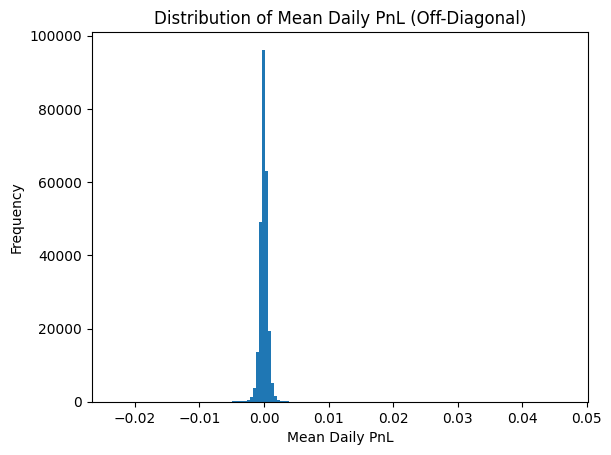

In [ ]:
plt.figure()
plt.hist(mean_vals, bins=150)
plt.title("Distribution of Mean Daily PnL (Off-Diagonal)")
plt.xlabel("Mean Daily PnL")
plt.ylabel("Frequency")
plt.show()

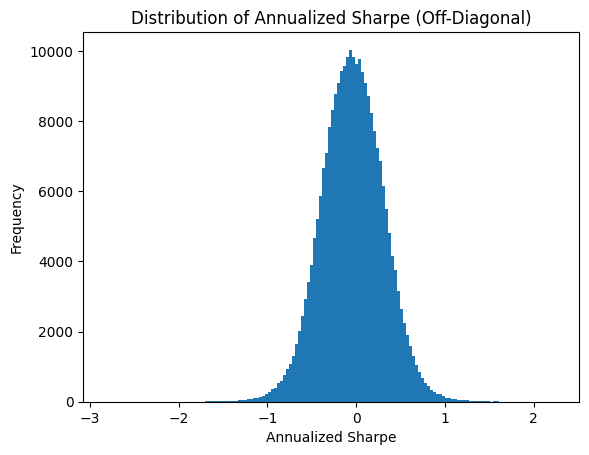

In [ ]:
plt.figure()
plt.hist(sr_vals, bins=150)
plt.title("Distribution of Annualized Sharpe (Off-Diagonal)")
plt.xlabel("Annualized Sharpe")
plt.ylabel("Frequency")
plt.show()

In [ ]:
print("Mean Sharpe:", np.mean(sr_vals))
print("Std Sharpe:", np.std(sr_vals))

print("95th percentile:", np.percentile(sr_vals, 95))
print("99th percentile:", np.percentile(sr_vals, 99))
print("Max Sharpe:", np.max(sr_vals))
print("Min Sharpe:", np.min(sr_vals))

Mean Sharpe: -0.038016494
Std Sharpe: 0.3502854
95th percentile: 0.5280701
99th percentile: 0.79253674
Max Sharpe: 2.257863
Min Sharpe: -2.8220465
